# Chapter 13 example: planar zero-field Ising inference via even subgraphs

For a zero-field Ising model,

$$
Z=\sum_x \exp\left(\sum_{e=(i,j)}J_e x_i x_j\right),
$$

the high-temperature expansion gives

$$
Z=2^{|V|}\prod_e\cosh J_e\;\sum_{F\subseteq E:\,\deg_F(v)\text{ even}}\prod_{e\in F}\tanh J_e.
$$

For planar graphs the even-subgraph sum can be converted to a weighted perfect-matching problem and evaluated by Pfaffian/determinant methods. Here we verify the exact even-subgraph identity directly on a small planar graph; the chapter explains how planarity turns this identity into a polynomial algorithm.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import product
from scipy.optimize import minimize, linprog

CWD=Path.cwd()
NOTEBOOK_DIR=CWD if CWD.name.startswith('ch') else CWD/'notebooks'/CWD.name if False else CWD
if not (NOTEBOOK_DIR/'figs').exists() and (CWD/'notebooks').exists():
    # infer chapter directory from notebook working directory only when launched at repo root
    raise RuntimeError('Run this notebook from its chapter directory, e.g. notebooks/ch10/.')
FIG_DIR=NOTEBOOK_DIR/'figs'; FIG_DIR.mkdir(parents=True,exist_ok=True)
RNG=np.random.default_rng(577)
NODE_COLOR='#34495e'
plt.rcParams.update({'font.size':14,'axes.titlesize':17,'axes.labelsize':15,'xtick.labelsize':12,'ytick.labelsize':12,'legend.fontsize':12})
def save_figure(fig,stem):
    fig.savefig(FIG_DIR/f'{stem}.pdf',bbox_inches='tight')
    fig.savefig(FIG_DIR/f'{stem}.png',dpi=220,bbox_inches='tight')

In [2]:
# 2x3 planar grid
G=nx.grid_2d_graph(2,3); mapping={v:i for i,v in enumerate(G.nodes())}; G=nx.relabel_nodes(G,mapping); edges=list(G.edges()); n=G.number_of_nodes(); J={e:0.25+0.08*k for k,e in enumerate(edges)}
states=np.array(list(product([-1,1],repeat=n)))
Z_enum=sum(np.exp(sum(J[e]*x[e[0]]*x[e[1]] for e in edges)) for x in states)
even=[]; val=0
for mask in range(1<<len(edges)):
 F=[edges[k] for k in range(len(edges)) if mask>>k&1]; H=nx.Graph(); H.add_nodes_from(G.nodes()); H.add_edges_from(F)
 if all(H.degree(v)%2==0 for v in H.nodes()):
  wt=np.prod([np.tanh(J[e]) for e in F]) if F else 1.; even.append((F,wt)); val+=wt
Z_even=(2**n)*np.prod([np.cosh(J[e]) for e in edges])*val
print('enumeration',Z_enum,'even-subgraph expansion',Z_even,'difference',abs(Z_enum-Z_even)); assert np.allclose(Z_enum,Z_even)

enumeration 166.6566486706257 even-subgraph expansion 166.6566486706258 difference 8.526512829121202e-14


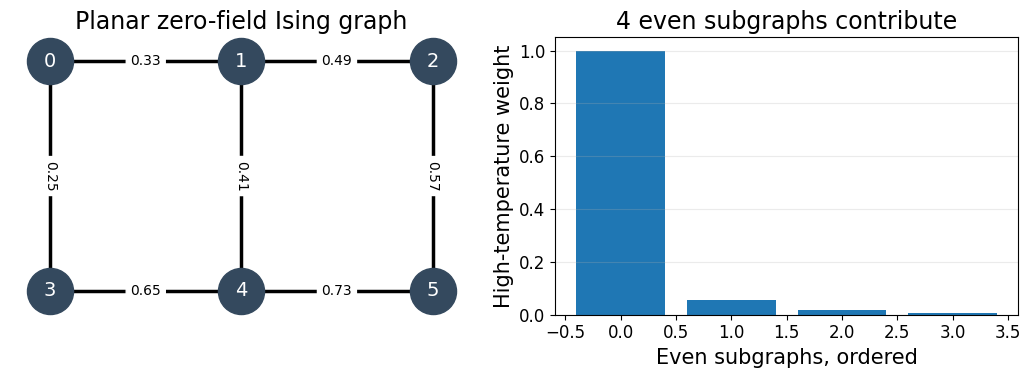

In [3]:
pos={mapping[(r,c)]:(c,-r) for r in range(2) for c in range(3)}; fig,axes=plt.subplots(1,2,figsize=(10.5,4))
nx.draw_networkx(G,pos,node_color=NODE_COLOR,font_color='white',node_size=1100,font_size=14,width=2.5,ax=axes[0]); nx.draw_networkx_edge_labels(G,pos,edge_labels={e:f'{J[e]:.2f}' for e in edges},font_size=10,ax=axes[0]); axes[0].set_title('Planar zero-field Ising graph'); axes[0].axis('off')
weights=np.array([w for _,w in even]); axes[1].bar(np.arange(len(weights)),np.sort(weights)[::-1]); axes[1].set_xlabel('Even subgraphs, ordered'); axes[1].set_ylabel('High-temperature weight'); axes[1].set_title(f'{len(even)} even subgraphs contribute'); axes[1].grid(axis='y',alpha=.25); fig.tight_layout(); save_figure(fig,'ch13_03_planar_even_subgraphs'); plt.show()

## Exercises

1. Add a nonzero magnetic field and identify exactly which step of the even-subgraph simplification fails.
2. Increase the grid to $3\times 3$ and compare the cost of state enumeration with even-subgraph enumeration.
3. **Challenge.** Implement the Fisher/Kasteleyn reduction to a dimer model and evaluate the corresponding Pfaffian for a small planar instance.